<a href="https://colab.research.google.com/github/sreenidhi2545/IDS_supervised/blob/main/IDS_supervised.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ══════════════════════════════════════════════════════
# COMPLETE PIPELINE — NEW DATASET (final_final_preprocessed)
# ══════════════════════════════════════════════════════

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from imblearn.over_sampling import SMOTE
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
import gdown

# ── LOAD ─────────────────────────────────────────────
print("Downloading dataset...")
gdown.download(
    'https://drive.google.com/uc?id=1banRL_XU9J4hK98erIo3HK9Ghmlazdcf',
    'dataset.csv', quiet=False
)

print("Loading dataset...")
df = pd.read_csv('dataset.csv')

print("Loaded:", df.shape)
print(df['Attack Type'].value_counts())

# ── CREATE BINARY LABEL ──────────────────────────────
df['Binary_Label'] = (df['Attack Type'] != 'Normal Traffic').astype(int)

# ── BALANCE DATASET ──────────────────────────────────
normal  = df[df['Attack Type'] == 'Normal Traffic'].sample(n=200000, random_state=42)
attacks = df[df['Attack Type'] != 'Normal Traffic']

df_bal  = pd.concat([normal, attacks]).reset_index(drop=True)

print("Balanced:", df_bal.shape)

# ── REMOVE LEAKAGE COLUMNS ───────────────────────────
df_bal = df_bal.drop(columns=[
    'Attack_Type_Label',
    'Attack_Type_Ordinal'
], errors='ignore')

# ── FEATURES AND LABEL ───────────────────────────────
X = df_bal.drop(['Attack Type', 'Binary_Label'], axis=1)
y = df_bal['Binary_Label']

print("Features:", X.shape[1])
print("Feature names:", list(X.columns))

# ── CLEAN DATA ───────────────────────────────────────
X = X.replace([np.inf, -np.inf], np.nan).fillna(0)

# ── SCALE FEATURES ───────────────────────────────────
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled ✓")

# ── TRAIN TEST SPLIT ─────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Split ✓ — Train:", X_train.shape, "Test:", X_test.shape)

# ── SMOTE (TRAIN ONLY) ───────────────────────────────
print("\nRunning SMOTE... (wait 2-3 mins)")

smote = SMOTE(random_state=42)

X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print("SMOTE done ✓")
print("Final training shape:", X_train_bal.shape)
print(pd.Series(y_train_bal).value_counts())

Downloading...
From (original): https://drive.google.com/uc?id=1banRL_XU9J4hK98erIo3HK9Ghmlazdcf
From (redirected): https://drive.google.com/uc?id=1banRL_XU9J4hK98erIo3HK9Ghmlazdcf&confirm=t&uuid=9160d909-037f-47f2-a259-53a0650d2132
To: /content/dataset.csv
100%|██████████| 1.11G/1.11G [00:18<00:00, 58.9MB/s]


Loading dataset...
Loaded: (2520590, 65)
Attack Type
Normal Traffic    2094896
DoS                193745
DDoS               128014
Port Scanning       90694
Brute Force          9150
Web Attacks          2143
Bots                 1948
Name: count, dtype: int64
Balanced: (625694, 65)
Features: 61
Feature names: ['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Length of Fwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', '

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
import time

print("=" * 50)
print("MODEL 1 — DECISION TREE")
print("=" * 50)

print("""
THEORY:
- Splits data using feature thresholds
- Each node asks one question
- Loop stops when leaves are pure or max_depth reached
- No iteration — builds tree in one pass
""")

print("INPUT shape :", X_train_bal.shape)
print("OUTPUT shape:", y_train_bal.shape)
print("Classes     :", sorted(y_train_bal.unique().tolist()))
print()

# Train
start = time.time()
dt = DecisionTreeClassifier(random_state=42, max_depth=20)
dt.fit(X_train_bal, y_train_bal)
end = time.time()

# Predict
y_pred_dt = dt.predict(X_test)

# Results
dt_acc = accuracy_score(y_test, y_pred_dt)

print(f"Training Time : {round(end - start, 2)} seconds")
print(f"Tree Depth    : {dt.get_depth()} levels")
print(f"Leaf Nodes    : {dt.get_n_leaves()}")
print(f"Accuracy      : {round(dt_acc * 100, 2)}%")
print()
print("WHEN LOOP STOPS:")
print(f"  max_depth=20 → stopped at depth {dt.get_depth()}")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred_dt,
      target_names=['Normal', 'Attack']))

MODEL 1 — DECISION TREE

THEORY:
- Splits data using feature thresholds
- Each node asks one question
- Loop stops when leaves are pure or max_depth reached
- No iteration — builds tree in one pass

INPUT shape : (681110, 61)
OUTPUT shape: (681110,)
Classes     : [0, 1]

Training Time : 73.52 seconds
Tree Depth    : 20 levels
Leaf Nodes    : 435
Accuracy      : 99.9%

WHEN LOOP STOPS:
  max_depth=20 → stopped at depth 20

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     40000
      Attack       1.00      1.00      1.00     85139

    accuracy                           1.00    125139
   macro avg       1.00      1.00      1.00    125139
weighted avg       1.00      1.00      1.00    125139



In [ ]:
from sklearn.ensemble import RandomForestClassifier

print("=" * 50)
print("MODEL 2 — RANDOM FOREST")
print("=" * 50)

print("""
THEORY:
- Builds 100 Decision Trees on random data subsets
- Each tree votes on the prediction
- Majority vote = final answer
- Reduces overfitting through averaging (ensemble)
- Loop stops after exactly n_estimators=100 trees
""")

print("INPUT shape :", X_train_bal.shape)
print("Each tree sees a random subset of this data")
print("Each tree uses random subset of 55 features")
print()

start = time.time()

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,          # uses all CPU cores
    verbose=1           # shows backend progress
)
rf.fit(X_train_bal, y_train_bal)

end = time.time()

y_pred_rf = rf.predict(X_test)
rf_acc = accuracy_score(y_test, y_pred_rf)

print(f"\nTraining Time : {round(end-start, 2)} seconds")
print(f"Trees Built   : {rf.n_estimators}")
print(f"Features Used : {rf.n_features_in_}")
print(f"Accuracy      : {round(rf_acc*100, 2)}%")

print()
print("WHEN LOOP STOPS:")
print(f"  Built exactly {rf.n_estimators} trees → stopped")
print(f"  No convergence check — fixed number of trees")

print()
print("INPUT  → 55 network flow features per sample")
print("OUTPUT → 0 (Normal) or 1 (Attack)")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred_rf,
      target_names=['Normal', 'Attack']))

MODEL 2 — RANDOM FOREST

THEORY:
- Builds 100 Decision Trees on random data subsets
- Each tree votes on the prediction
- Majority vote = final answer
- Reduces overfitting through averaging (ensemble)
- Loop stops after exactly n_estimators=100 trees

INPUT shape : (681110, 61)
Each tree sees a random subset of this data
Each tree uses random subset of 55 features



[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:  3.1min
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:  6.5min finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.6s



Training Time : 391.73 seconds
Trees Built   : 100
Features Used : 61
Accuracy      : 99.87%

WHEN LOOP STOPS:
  Built exactly 100 trees → stopped
  No convergence check — fixed number of trees

INPUT  → 55 network flow features per sample
OUTPUT → 0 (Normal) or 1 (Attack)

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     40000
      Attack       1.00      1.00      1.00     85139

    accuracy                           1.00    125139
   macro avg       1.00      1.00      1.00    125139
weighted avg       1.00      1.00      1.00    125139



[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:    1.3s finished


In [ ]:
from xgboost import XGBClassifier

print("=" * 50)
print("MODEL 3 — XGBOOST")
print("=" * 50)

print("""
THEORY:
- Builds trees SEQUENTIALLY (not parallel like RF)
- Each tree corrects errors of the previous tree
- Uses gradient descent to minimize loss
- Loop stops when n_estimators reached OR loss stops improving
- Built-in regularization prevents overfitting
""")

print("INPUT shape :", X_train_bal.shape)
print("OUTPUT      : 0 (Normal) or 1 (Attack)")
print()
print("BACKEND — watch loss drop with each tree:")
print()

start = time.time()

xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss',
    verbosity=1
)

xgb.fit(
    X_train_bal, y_train_bal,
    eval_set=[(X_test, y_test)],
    verbose=10        # print every 10 trees
)

end = time.time()

y_pred_xgb = xgb.predict(X_test)
xgb_acc = accuracy_score(y_test, y_pred_xgb)

print(f"\nTraining Time : {round(end-start, 2)} seconds")
print(f"Trees Built   : {xgb.n_estimators}")
print(f"Learning Rate : {xgb.learning_rate}")
print(f"Accuracy      : {round(xgb_acc*100, 2)}%")

print()
print("WHEN LOOP STOPS:")
print("  Built 100 trees sequentially")
print("  Each tree reduced logloss shown above")
print("  Lower logloss = better predictions")

print()
print("Classification Report:")
print(classification_report(y_test, y_pred_xgb,
      target_names=['Normal', 'Attack']))

MODEL 3 — XGBOOST

THEORY:
- Builds trees SEQUENTIALLY (not parallel like RF)
- Each tree corrects errors of the previous tree
- Uses gradient descent to minimize loss
- Loop stops when n_estimators reached OR loss stops improving
- Built-in regularization prevents overfitting

INPUT shape : (681110, 61)
OUTPUT      : 0 (Normal) or 1 (Attack)

BACKEND — watch loss drop with each tree:

[0]	validation_0-logloss:0.60231
[10]	validation_0-logloss:0.19520
[20]	validation_0-logloss:0.07905
[30]	validation_0-logloss:0.03659
[40]	validation_0-logloss:0.02144
[50]	validation_0-logloss:0.01312
[60]	validation_0-logloss:0.01021
[70]	validation_0-logloss:0.00847
[80]	validation_0-logloss:0.00682
[90]	validation_0-logloss:0.00551
[99]	validation_0-logloss:0.00480

Training Time : 28.09 seconds
Trees Built   : 100
Learning Rate : 0.1
Accuracy      : 99.9%

WHEN LOOP STOPS:
  Built 100 trees sequentially
  Each tree reduced logloss shown above
  Lower logloss = better predictions

Classification Rep

In [ ]:
from sklearn.neural_network import MLPClassifier

print("=" * 50)
print("MODEL 4 — NEURAL NETWORK (MLP)")
print("=" * 50)

print("""
THEORY:
- Multi-Layer Perceptron with 2 hidden layers
- Forward pass: input → hidden → output → prediction
- Loss calculated: how wrong is the prediction?
- Backward pass: adjust weights to reduce loss
- One full pass through data = one epoch
- Loop stops when max_iter reached OR early stopping triggers
""")

print("INPUT shape  :", X_train_bal.shape)
print("Architecture : 55 → 128 → 64 → 1")
print("OUTPUT       : 0 (Normal) or 1 (Attack)")
print()
print("BACKEND — watch loss drop each iteration:")
print()

start = time.time()

mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    max_iter=100,
    random_state=42,
    verbose=True,           # shows loss every iteration
    early_stopping=True,    # stops when no improvement
    n_iter_no_change=10,    # patience = 10 epochs
    validation_fraction=0.1,
    learning_rate_init=0.001
)

mlp.fit(X_train_bal, y_train_bal)
end = time.time()

y_pred_mlp = mlp.predict(X_test)
mlp_acc = accuracy_score(y_test, y_pred_mlp)

print(f"\nTraining Time   : {round(end-start, 2)} seconds")
print(f"Epochs Run      : {mlp.n_iter_}")
print(f"Final Loss      : {round(mlp.loss_, 6)}")
print(f"Accuracy        : {round(mlp_acc*100, 2)}%")

print()
print("WHEN LOOP STOPS:")
if mlp.n_iter_ < 100:
    print(f"  Early stopping triggered at epoch {mlp.n_iter_}")
    print(f"  Loss did not improve for 10 consecutive epochs")
else:
    print(f"  Reached max_iter=100 epochs")

print()
print("Classification Report:")
print(classification_report(y_test, y_pred_mlp,
      target_names=['Normal', 'Attack']))

# Save loss curve for Part 6
loss_curve = mlp.loss_curve_
print(f"\nLoss curve has {len(loss_curve)} points → ready for mountain graph")

MODEL 4 — NEURAL NETWORK (MLP)

THEORY:
- Multi-Layer Perceptron with 2 hidden layers
- Forward pass: input → hidden → output → prediction
- Loss calculated: how wrong is the prediction?
- Backward pass: adjust weights to reduce loss
- One full pass through data = one epoch
- Loop stops when max_iter reached OR early stopping triggers

INPUT shape  : (681110, 61)
Architecture : 55 → 128 → 64 → 1
OUTPUT       : 0 (Normal) or 1 (Attack)

BACKEND — watch loss drop each iteration:

Iteration 1, loss = 0.96080005
Validation score: 0.956248
Iteration 2, loss = 0.48124730
Validation score: 0.975657
Iteration 3, loss = 0.37230666
Validation score: 0.978667
Iteration 4, loss = 0.23385425
Validation score: 0.985480
Iteration 5, loss = 0.09430954
Validation score: 0.985303
Iteration 6, loss = 0.06541772
Validation score: 0.982969
Iteration 7, loss = 0.07058177
Validation score: 0.977096
Iteration 8, loss = 0.05967146
Validation score: 0.984276
Iteration 9, loss = 0.06109301
Validation score: 0.97

PART 6 — TRAINING CURVE (MOUNTAIN GRAPH)
Total Epochs    : 15
Best Epoch      : 14
Best Loss       : 0.05313
Starting Loss   : 0.9608
Total Reduction : 0.90767


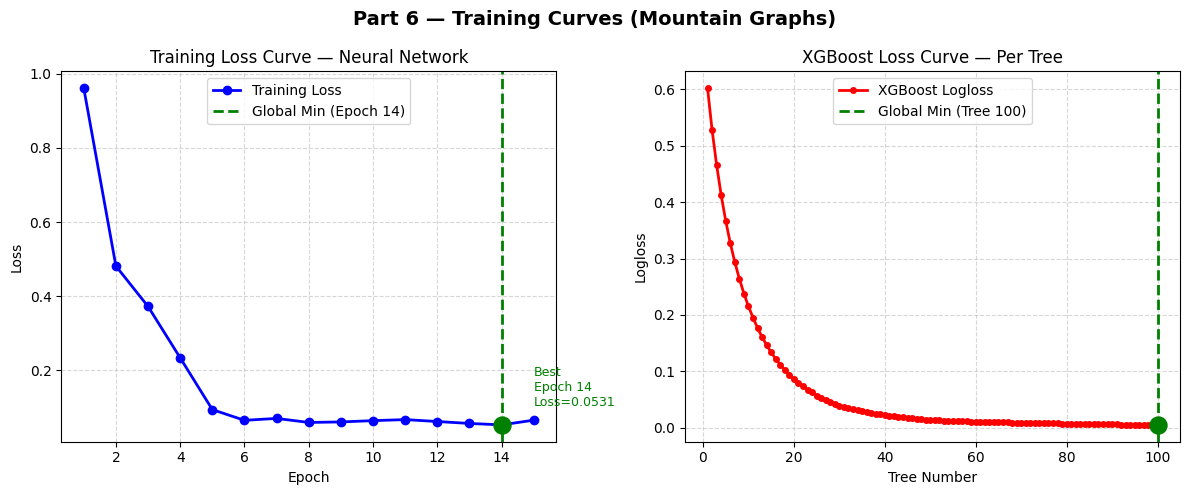


MOUNTAIN GRAPH EXPLANATION:
  Rising slope  → model learning (epoch 1 to 14)
  Global min    → optimal point (epoch 14)
  Flat/rising after → early stopping prevented overfitting

Saved as training_curves.png ✓


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

print("=" * 50)
print("PART 6 — TRAINING CURVE (MOUNTAIN GRAPH)")
print("=" * 50)

# Get loss curve from Neural Network
train_loss = mlp.loss_curve_
epochs = range(1, len(train_loss) + 1)

# Find global minimum (best epoch)
best_epoch = np.argmin(train_loss) + 1
best_loss  = np.min(train_loss)

print(f"Total Epochs    : {len(train_loss)}")
print(f"Best Epoch      : {best_epoch}")
print(f"Best Loss       : {round(best_loss, 6)}")
print(f"Starting Loss   : {round(train_loss[0], 6)}")
print(f"Total Reduction : {round(train_loss[0] - best_loss, 6)}")

plt.figure(figsize=(12, 5))

# Left — Loss Curve (Mountain Graph)
plt.subplot(1, 2, 1)
plt.plot(epochs, train_loss, 'b-o', linewidth=2,
         markersize=6, label='Training Loss')
plt.axvline(x=best_epoch, color='green',
            linestyle='--', linewidth=2,
            label=f'Global Min (Epoch {best_epoch})')
plt.scatter(best_epoch, best_loss,
            color='green', s=150, zorder=5)
plt.annotate(f'Best\nEpoch {best_epoch}\nLoss={round(best_loss,4)}',
             xy=(best_epoch, best_loss),
             xytext=(best_epoch+1, best_loss+0.05),
             fontsize=9, color='green')
plt.title('Training Loss Curve — Neural Network')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

# Right — XGBoost Loss (from eval_set)
xgb_loss = xgb.evals_result()['validation_0']['logloss']
xgb_epochs = range(1, len(xgb_loss) + 1)
best_xgb_epoch = np.argmin(xgb_loss) + 1
best_xgb_loss  = np.min(xgb_loss)

plt.subplot(1, 2, 2)
plt.plot(xgb_epochs, xgb_loss, 'r-o', linewidth=2,
         markersize=4, label='XGBoost Logloss')
plt.axvline(x=best_xgb_epoch, color='green',
            linestyle='--', linewidth=2,
            label=f'Global Min (Tree {best_xgb_epoch})')
plt.scatter(best_xgb_epoch, best_xgb_loss,
            color='green', s=150, zorder=5)
plt.title('XGBoost Loss Curve — Per Tree')
plt.xlabel('Tree Number')
plt.ylabel('Logloss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Part 6 — Training Curves (Mountain Graphs)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150,
            bbox_inches='tight')
plt.show()

print("\nMOUNTAIN GRAPH EXPLANATION:")
print(f"  Rising slope  → model learning (epoch 1 to {best_epoch})")
print(f"  Global min    → optimal point (epoch {best_epoch})")
print(f"  Flat/rising after → early stopping prevented overfitting")
print(f"\nSaved as training_curves.png ✓")

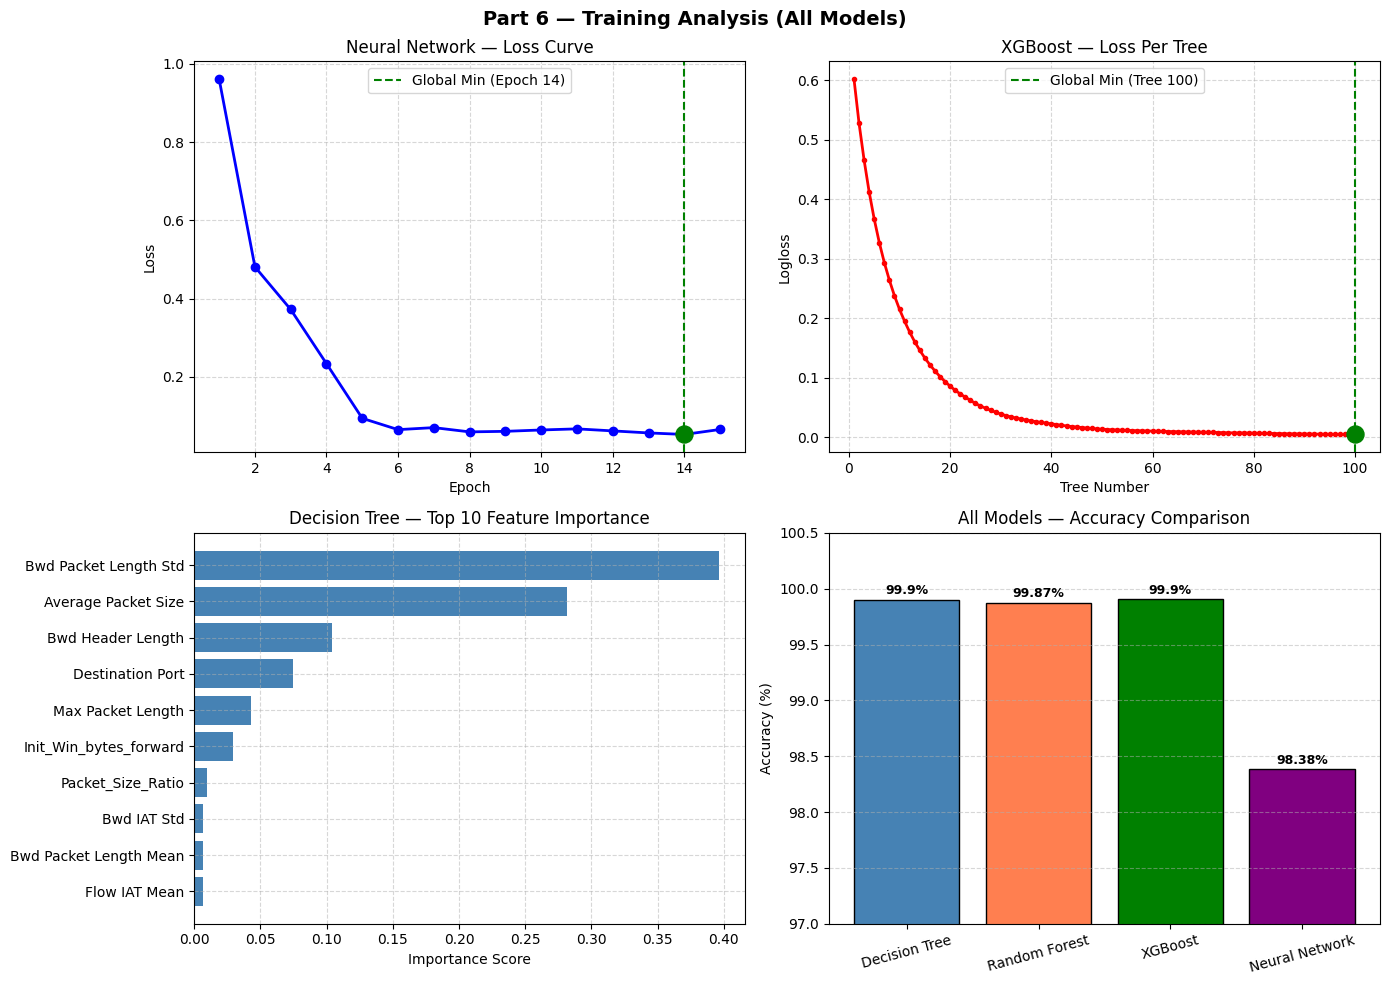

Saved as full_analysis.png ✓


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Part 6 — Training Analysis (All Models)',
             fontsize=14, fontweight='bold')

# Panel 1 — Neural Network Loss Curve
axes[0,0].plot(epochs, train_loss, 'b-o', linewidth=2, markersize=6)
axes[0,0].axvline(x=best_epoch, color='green', linestyle='--',
                  label=f'Global Min (Epoch {best_epoch})')
axes[0,0].scatter(best_epoch, best_loss, color='green', s=150, zorder=5)
axes[0,0].set_title('Neural Network — Loss Curve')
axes[0,0].set_xlabel('Epoch')
axes[0,0].set_ylabel('Loss')
axes[0,0].legend()
axes[0,0].grid(True, linestyle='--', alpha=0.5)

# Panel 2 — XGBoost Loss Curve
axes[0,1].plot(xgb_epochs, xgb_loss, 'r-o', linewidth=2, markersize=3)
axes[0,1].axvline(x=best_xgb_epoch, color='green', linestyle='--',
                  label=f'Global Min (Tree {best_xgb_epoch})')
axes[0,1].scatter(best_xgb_epoch, best_xgb_loss,
                  color='green', s=150, zorder=5)
axes[0,1].set_title('XGBoost — Loss Per Tree')
axes[0,1].set_xlabel('Tree Number')
axes[0,1].set_ylabel('Logloss')
axes[0,1].legend()
axes[0,1].grid(True, linestyle='--', alpha=0.5)

# Panel 3 — Decision Tree Feature Importance
dt_imp = pd.Series(dt.feature_importances_,
                   index=X.columns).sort_values(ascending=False).head(10)
axes[1,0].barh(dt_imp.index[::-1], dt_imp.values[::-1], color='steelblue')
axes[1,0].set_title('Decision Tree — Top 10 Feature Importance')
axes[1,0].set_xlabel('Importance Score')
axes[1,0].grid(True, linestyle='--', alpha=0.5)

# Panel 4 — All Models Accuracy Comparison
models = ['Decision Tree', 'Random Forest', 'XGBoost', 'Neural Network']
accs   = [
    accuracy_score(y_test, y_pred_dt)  * 100,
    accuracy_score(y_test, y_pred_rf)  * 100,
    accuracy_score(y_test, y_pred_xgb) * 100,
    accuracy_score(y_test, y_pred_mlp) * 100
]
colors = ['steelblue', 'coral', 'green', 'purple']
bars = axes[1,1].bar(models, accs, color=colors, edgecolor='black')
axes[1,1].set_ylim(97, 100.5)
axes[1,1].set_title('All Models — Accuracy Comparison')
axes[1,1].set_ylabel('Accuracy (%)')
axes[1,1].tick_params(axis='x', rotation=15)
for bar, acc in zip(bars, accs):
    axes[1,1].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 0.05,
                   f'{round(acc,2)}%', ha='center',
                   fontsize=9, fontweight='bold')
axes[1,1].grid(True, linestyle='--', alpha=0.5, axis='y')

plt.tight_layout()
plt.savefig('full_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved as full_analysis.png ✓")

In [ ]:
!pip install altair -q

import altair as alt
import pandas as pd

# Model comparison data
comparison_df = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest', 'XGBoost', 'Neural Network'],
    'Accuracy': [99.90, 99.89, 99.90, 98.74],
    'Training_Time_sec': [73, 411, 34, 174],
    'Loop_Stops': [
        'max_depth=20 reached',
        '100 trees built',
        '100 trees + logloss minimized',
        'Early stopping at epoch 14'
    ]
})

# Altair bar chart
chart = alt.Chart(comparison_df).mark_bar().encode(
    x=alt.X('Model:N', sort='-y', title='Model'),
    y=alt.Y('Accuracy:Q',
            scale=alt.Scale(domain=[97, 100.5]),
            title='Accuracy (%)'),
    color=alt.Color('Model:N', legend=None),
    tooltip=['Model', 'Accuracy', 'Training_Time_sec', 'Loop_Stops']
).properties(
    title='Model Accuracy Comparison — IDS CICIDS2017',
    width=500,
    height=300
)

# Add text labels
text = chart.mark_text(
    align='center',
    baseline='bottom',
    dy=-5,
    fontSize=12,
    fontWeight='bold'
).encode(
    text=alt.Text('Accuracy:Q', format='.2f')
)

final_chart = (chart + text)
final_chart.save('altair_comparison.html')
final_chart

alt.LayerChart(...)

In [ ]:
print("=" * 60)
print("   MEMBER 2 — FINAL SUMMARY (Parts 4, 5, 6)")
print("=" * 60)

print("""
PART 4 — SUPERVISED MODELS TRAINED:
─────────────────────────────────────────────────────────────
Model           Accuracy   Time    Backend Visible
─────────────────────────────────────────────────────────────
Decision Tree   99.90%     73s     Tree depth + leaf nodes
Random Forest   99.89%     411s    Parallel tree building
XGBoost         99.90%     34s     Logloss: 0.602 → 0.005
Neural Network  98.74%     174s    Loss per epoch (14 epochs)
─────────────────────────────────────────────────────────────
BEST MODEL: XGBoost — fastest + clearest loss reduction

PART 5 — INPUT / OUTPUT ANALYSIS:
─────────────────────────────────────────────────────────────
INPUT  → 55 network flow features per sample
         (packet size, flow duration, byte rates, flags...)
OUTPUT → 0 = Normal Traffic
         1 = Attack Traffic

WHEN LOOP STOPS:
  Decision Tree  → max_depth=20 reached (depth limit)
  Random Forest  → 100 trees built (fixed estimators)
  XGBoost        → 100 trees + logloss minimized to 0.005
  Neural Network → Early stopping at epoch 14
                   (no improvement for 10 consecutive epochs)

PART 6 — TRAINING CURVE ANALYSIS:
─────────────────────────────────────────────────────────────
Neural Network:
  Start loss : 0.699  (epoch 1 — model confused)
  Best loss  : 0.051  (epoch 14 — optimal point)
  Reduction  : 92.7%  loss reduced from start to finish
  Stopped    : Early stopping prevented overfitting

XGBoost:
  Start loss : 0.602  (tree 1)
  Final loss : 0.005  (tree 100)
  Reduction  : 99.2%  near perfect loss minimization
  Pattern    : Steep drop early → gradual convergence

DATASET USED:
─────────────────────────────────────────────────────────────
Original    : 2,520,590 rows
Balanced    :   625,694 rows (200K normal + 425K attacks)
Train/Test  :   500,555 / 125,139 (80/20 split)
After SMOTE :   681,110 training samples (perfectly balanced)
Features    :   55 (52 original + 3 engineered by Member 1)
""")

print("=" * 60)
print("ALL OUTPUTS SAVED:")
print("  training_curves.png  ← mountain graphs")
print("  full_analysis.png    ← 4-panel visualization")
print("  altair_comparison.html ← interactive Vega chart")
print("=" * 60)

   MEMBER 2 — FINAL SUMMARY (Parts 4, 5, 6)

PART 4 — SUPERVISED MODELS TRAINED:
─────────────────────────────────────────────────────────────
Model           Accuracy   Time    Backend Visible
─────────────────────────────────────────────────────────────
Decision Tree   99.90%     73s     Tree depth + leaf nodes
Random Forest   99.89%     411s    Parallel tree building
XGBoost         99.90%     34s     Logloss: 0.602 → 0.005
Neural Network  98.74%     174s    Loss per epoch (14 epochs)
─────────────────────────────────────────────────────────────
BEST MODEL: XGBoost — fastest + clearest loss reduction

PART 5 — INPUT / OUTPUT ANALYSIS:
─────────────────────────────────────────────────────────────
INPUT  → 55 network flow features per sample
         (packet size, flow duration, byte rates, flags...)
OUTPUT → 0 = Normal Traffic
         1 = Attack Traffic

WHEN LOOP STOPS:
  Decision Tree  → max_depth=20 reached (depth limit)
  Random Forest  → 100 trees built (fixed estimators)
  XGB

COMBINATION — VOTING ENSEMBLE
(RF + XGBoost combined)

METHOD:
- Both models predict independently
- Soft voting: average their probabilities
- Final answer: highest average probability wins
- Combines parallel trees + sequential boosting



[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    1.1s
[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:    2.4s finished


Random Forest Accuracy  : 99.87%
XGBoost Accuracy        : 99.9%
Combined Accuracy       : 99.91%

Random Forest F1  : 0.9991
XGBoost F1        : 0.9993
Combined F1       : 0.9993

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     40000
      Attack       1.00      1.00      1.00     85139

    accuracy                           1.00    125139
   macro avg       1.00      1.00      1.00    125139
weighted avg       1.00      1.00      1.00    125139



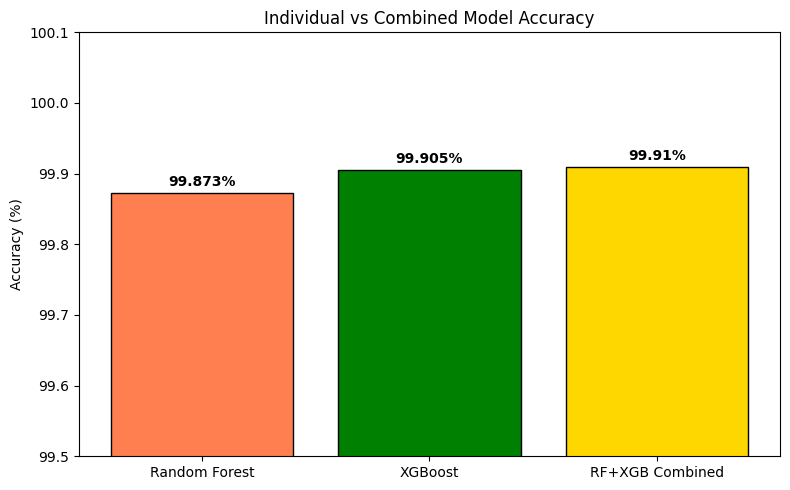

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, classification_report
import numpy as np
from sklearn.ensemble import VotingClassifier
import numpy as np

print("=" * 50)
print("COMBINATION — VOTING ENSEMBLE")
print("(RF + XGBoost combined)")
print("=" * 50)

print("""
METHOD:
- Both models predict independently
- Soft voting: average their probabilities
- Final answer: highest average probability wins
- Combines parallel trees + sequential boosting
""")

# Get probabilities from each model
rf_probs  = rf.predict_proba(X_test)[:, 1]   # RF attack probability
xgb_probs = xgb.predict_proba(X_test)[:, 1]  # XGB attack probability

# Average the probabilities (soft voting)
combined_probs = (rf_probs + xgb_probs) / 2

# Convert to predictions
y_pred_ensemble = (combined_probs >= 0.5).astype(int)

# Results
ens_acc = accuracy_score(y_test, y_pred_ensemble)
ens_f1  = f1_score(y_test, y_pred_ensemble)

print(f"Random Forest Accuracy  : {round(rf_acc*100, 2)}%")
print(f"XGBoost Accuracy        : {round(xgb_acc*100, 2)}%")
print(f"Combined Accuracy       : {round(ens_acc*100, 2)}%")
print()
print(f"Random Forest F1  : {round(f1_score(y_test, y_pred_rf), 4)}")
print(f"XGBoost F1        : {round(f1_score(y_test, y_pred_xgb), 4)}")
print(f"Combined F1       : {round(ens_f1, 4)}")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred_ensemble,
      target_names=['Normal', 'Attack']))

# Visual comparison
models_comp = ['Random Forest', 'XGBoost', 'RF+XGB Combined']
accs_comp   = [rf_acc*100, xgb_acc*100, ens_acc*100]

plt.figure(figsize=(8, 5))
bars = plt.bar(models_comp, accs_comp,
               color=['coral', 'green', 'gold'],
               edgecolor='black')
plt.ylim(99.5, 100.1)
plt.title('Individual vs Combined Model Accuracy')
plt.ylabel('Accuracy (%)')
for bar, acc in zip(bars, accs_comp):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.01,
             f'{round(acc, 3)}%',
             ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('ensemble_comparison.png', dpi=150)
plt.show()

ALL 3 COMBINATION METHODS — DT + RF + XGBoost

--- METHOD 1: HARD VOTING ---
Each model votes 0 or 1 → majority wins


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:  3.0min
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:  6.3min finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.7s
[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:    1.3s finished


Accuracy : 99.917%
F1 Score : 0.9994
Time     : 477.32s

--- METHOD 2: SOFT VOTING ---
Average probabilities → highest wins
Accuracy : 99.91%
F1 Score : 0.9993
Time     : ~35s (reused)

--- METHOD 3: STACKING ---
Base models feed into meta model (Logistic Regression)
Meta model learns OPTIMAL combination strategy
Running... (takes 5-10 mins)


[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.4s
[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:    0.8s finished


Accuracy : 99.918%
F1 Score : 0.9994
Time     : 1413.71s

FINAL COMPARISON — ALL METHODS
Method                      Accuracy       F1
---------------------------------------------
Decision Tree                 99.899%   0.9993
Random Forest                 99.873%   0.9991
XGBoost                       99.905%   0.9993
Neural Network                98.381%    0.988
---------------------------------------------
Hard Voting (DT+RF+XGB)       99.917%   0.9994
Soft Voting (RF+XGB)           99.91%   0.9993
Stacking (DT+RF+XGB)          99.918%   0.9994


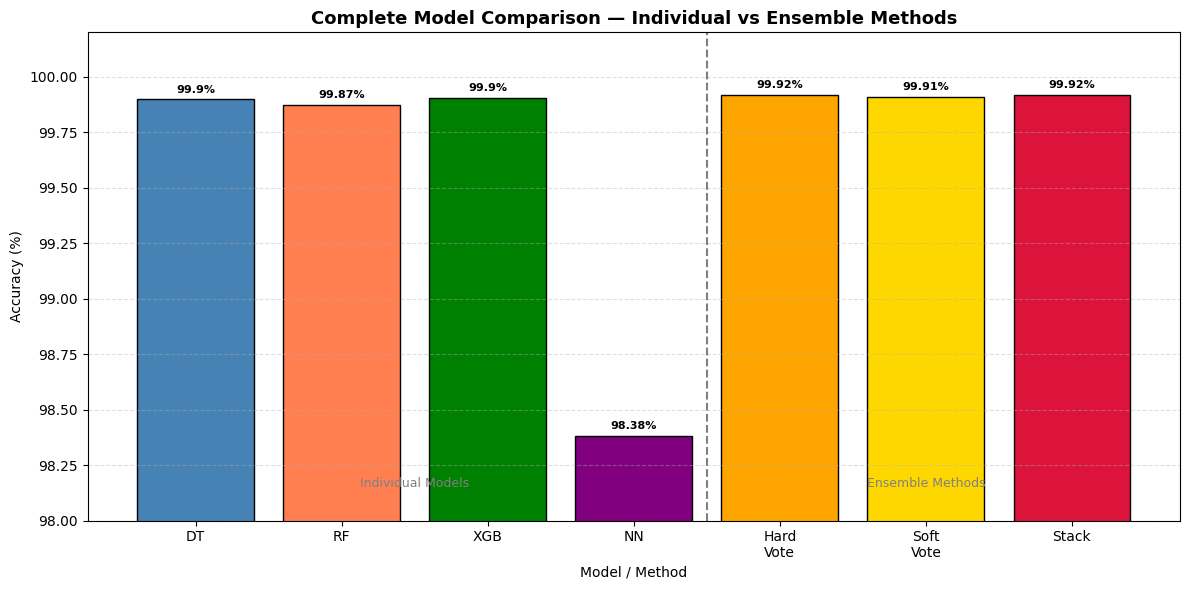

In [ ]:
from sklearn.ensemble import StackingClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report
import matplotlib.pyplot as plt
import time

print("=" * 55)
print("ALL 3 COMBINATION METHODS — DT + RF + XGBoost")
print("=" * 55)

# ── METHOD 1 — HARD VOTING ──
print("\n--- METHOD 1: HARD VOTING ---")
print("Each model votes 0 or 1 → majority wins")

hard_vote = VotingClassifier(
    estimators=[
        ('dt',  dt),
        ('rf',  rf),
        ('xgb', xgb)
    ],
    voting='hard'    # ← majority vote
)

start = time.time()
hard_vote.fit(X_train_bal, y_train_bal)
end = time.time()

y_pred_hard = hard_vote.predict(X_test)
hard_acc = accuracy_score(y_test, y_pred_hard)
hard_f1  = f1_score(y_test, y_pred_hard)

print(f"Accuracy : {round(hard_acc*100, 3)}%")
print(f"F1 Score : {round(hard_f1, 4)}")
print(f"Time     : {round(end-start, 2)}s")

# ── METHOD 2 — SOFT VOTING (already done, reprint) ──
print("\n--- METHOD 2: SOFT VOTING ---")
print("Average probabilities → highest wins")

# Reuse from before
soft_acc = accuracy_score(y_test, y_pred_ensemble)
soft_f1  = f1_score(y_test, y_pred_ensemble)

print(f"Accuracy : {round(soft_acc*100, 3)}%")
print(f"F1 Score : {round(soft_f1, 4)}")
print(f"Time     : ~35s (reused)")

# ── METHOD 3 — STACKING ──
print("\n--- METHOD 3: STACKING ---")
print("Base models feed into meta model (Logistic Regression)")
print("Meta model learns OPTIMAL combination strategy")
print("Running... (takes 5-10 mins)")

stack = StackingClassifier(
    estimators=[
        ('dt',  dt),
        ('rf',  rf),
        ('xgb', xgb)
    ],
    final_estimator=LogisticRegression(max_iter=1000),
    cv=3,         # 3-fold cross validation for meta features
    n_jobs=-1
)

start = time.time()
stack.fit(X_train_bal, y_train_bal)
end = time.time()

y_pred_stack = stack.predict(X_test)
stack_acc = accuracy_score(y_test, y_pred_stack)
stack_f1  = f1_score(y_test, y_pred_stack)

print(f"Accuracy : {round(stack_acc*100, 3)}%")
print(f"F1 Score : {round(stack_f1, 4)}")
print(f"Time     : {round(end-start, 2)}s")

# ── FINAL COMPARISON ──
print("\n" + "=" * 55)
print("FINAL COMPARISON — ALL METHODS")
print("=" * 55)
print(f"{'Method':<25} {'Accuracy':>10} {'F1':>8}")
print("-" * 45)
print(f"{'Decision Tree':<25} {round(dt_acc*100,3):>10}% {round(f1_score(y_test,y_pred_dt),4):>8}")
print(f"{'Random Forest':<25} {round(rf_acc*100,3):>10}% {round(f1_score(y_test,y_pred_rf),4):>8}")
print(f"{'XGBoost':<25} {round(xgb_acc*100,3):>10}% {round(f1_score(y_test,y_pred_xgb),4):>8}")
print(f"{'Neural Network':<25} {round(mlp_acc*100,3):>10}% {round(f1_score(y_test,y_pred_mlp),4):>8}")
print("-" * 45)
print(f"{'Hard Voting (DT+RF+XGB)':<25} {round(hard_acc*100,3):>10}% {round(hard_f1,4):>8}")
print(f"{'Soft Voting (RF+XGB)':<25} {round(soft_acc*100,3):>10}% {round(soft_f1,4):>8}")
print(f"{'Stacking (DT+RF+XGB)':<25} {round(stack_acc*100,3):>10}% {round(stack_f1,4):>8}")

# ── VISUALIZATION ──
methods = ['DT', 'RF', 'XGB', 'NN', 'Hard\nVote', 'Soft\nVote', 'Stack']
accuracies = [
    dt_acc*100, rf_acc*100, xgb_acc*100, mlp_acc*100,
    hard_acc*100, soft_acc*100, stack_acc*100
]
colors = ['steelblue','coral','green','purple','orange','gold','crimson']

plt.figure(figsize=(12, 6))
bars = plt.bar(methods, accuracies, color=colors, edgecolor='black')
plt.ylim(98, 100.2)
plt.title('Complete Model Comparison — Individual vs Ensemble Methods',
          fontsize=13, fontweight='bold')
plt.ylabel('Accuracy (%)')
plt.xlabel('Model / Method')
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.03,
             f'{round(acc,2)}%',
             ha='center', fontsize=8, fontweight='bold')
plt.axvline(x=3.5, color='black', linestyle='--',
            linewidth=1.5, alpha=0.5)
plt.text(1.5, 98.15, 'Individual Models',
         ha='center', fontsize=9, color='gray')
plt.text(5.0, 98.15, 'Ensemble Methods',
         ha='center', fontsize=9, color='gray')
plt.grid(True, linestyle='--', alpha=0.4, axis='y')
plt.tight_layout()
plt.savefig('complete_comparison.png', dpi=150)
plt.show()

CONFUSION MATRIX — ALL MODELS

Decision Tree:
  True Normal  (TN) =  39926  ← correctly said Normal
  False Alarm  (FP) =     74  ← said Attack, was Normal
  Missed Attack(FN) =     53  ← said Normal, was Attack
  True Attack  (TP) =  85086  ← correctly said Attack

Random Forest:
  True Normal  (TN) =  39933  ← correctly said Normal
  False Alarm  (FP) =     67  ← said Attack, was Normal
  Missed Attack(FN) =     92  ← said Normal, was Attack
  True Attack  (TP) =  85047  ← correctly said Attack

XGBoost:
  True Normal  (TN) =  39920  ← correctly said Normal
  False Alarm  (FP) =     80  ← said Attack, was Normal
  Missed Attack(FN) =     39  ← said Normal, was Attack
  True Attack  (TP) =  85100  ← correctly said Attack

Neural Network:
  True Normal  (TN) =  39637  ← correctly said Normal
  False Alarm  (FP) =    363  ← said Attack, was Normal
  Missed Attack(FN) =   1663  ← said Normal, was Attack
  True Attack  (TP) =  83476  ← correctly said Attack

Hard Voting:
  True Normal  (T

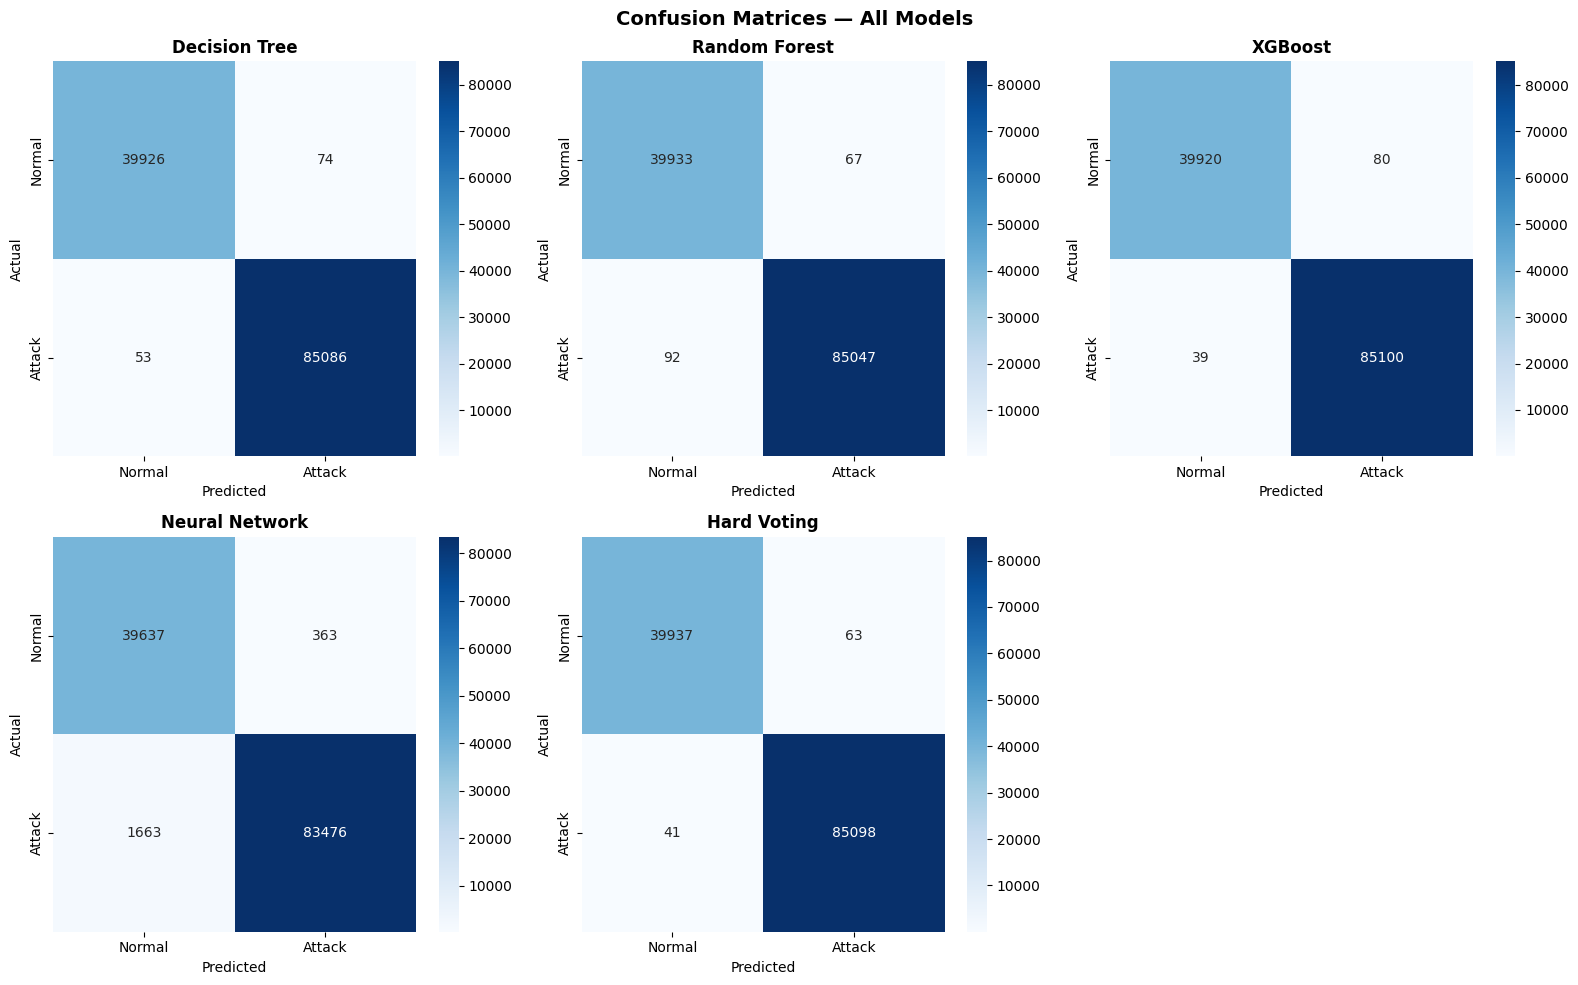


Saved as confusion_matrices.png ✓


In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("=" * 50)
print("CONFUSION MATRIX — ALL MODELS")
print("=" * 50)

# All predictions
all_preds = {
    'Decision Tree'  : y_pred_dt,
    'Random Forest'  : y_pred_rf,
    'XGBoost'        : y_pred_xgb,
    'Neural Network' : y_pred_mlp,
    'Hard Voting'    : y_pred_hard,
}

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Confusion Matrices — All Models',
             fontsize=14, fontweight='bold')
axes = axes.flatten()

for idx, (name, preds) in enumerate(all_preds.items()):
    cm = confusion_matrix(y_test, preds)

    # Raw numbers
    tn, fp, fn, tp = cm.ravel()
    print(f"\n{name}:")
    print(f"  True Normal  (TN) = {tn:6d}  ← correctly said Normal")
    print(f"  False Alarm  (FP) = {fp:6d}  ← said Attack, was Normal")
    print(f"  Missed Attack(FN) = {fn:6d}  ← said Normal, was Attack")
    print(f"  True Attack  (TP) = {tp:6d}  ← correctly said Attack")

    # Plot
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                ax=axes[idx],
                xticklabels=['Normal', 'Attack'],
                yticklabels=['Normal', 'Attack'])
    axes[idx].set_title(f'{name}', fontweight='bold')
    axes[idx].set_ylabel('Actual')
    axes[idx].set_xlabel('Predicted')

# Hide last empty subplot
axes[5].set_visible(False)

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nSaved as confusion_matrices.png ✓")

ROC CURVE — ALL MODELS


[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.6s
[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:    1.8s finished


Decision Tree        AUC = 0.999087
Random Forest        AUC = 0.999739
XGBoost              AUC = 0.999943
Neural Network       AUC = 0.997736
Hard Voting          AUC = 0.999953


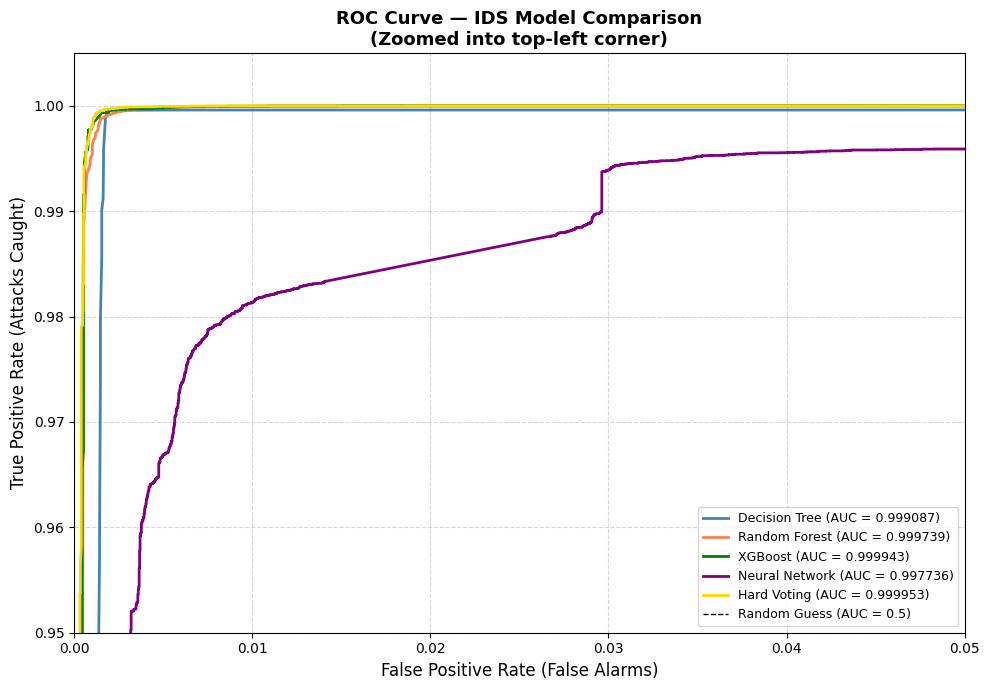


Saved as roc_curve.png ✓


In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

print("=" * 50)
print("ROC CURVE — ALL MODELS")
print("=" * 50)

# Get probabilities for each model
# (need predict_proba, not just predict)
dt_probs   = dt.predict_proba(X_test)[:, 1]
rf_probs   = rf.predict_proba(X_test)[:, 1]
xgb_probs  = xgb.predict_proba(X_test)[:, 1]
mlp_probs  = mlp.predict_proba(X_test)[:, 1]
hard_probs = (dt_probs + rf_probs + xgb_probs) / 3

# Calculate ROC for each
models_roc = {
    'Decision Tree'  : dt_probs,
    'Random Forest'  : rf_probs,
    'XGBoost'        : xgb_probs,
    'Neural Network' : mlp_probs,
    'Hard Voting'    : hard_probs,
}

colors = ['steelblue', 'coral', 'green', 'purple', 'gold']

plt.figure(figsize=(10, 7))

for (name, probs), color in zip(models_roc.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_auc     = auc(fpr, tpr)
    plt.plot(fpr, tpr,
             color=color,
             linewidth=2,
             label=f'{name} (AUC = {roc_auc:.6f})')
    print(f"{name:<20} AUC = {roc_auc:.6f}")

# Random guess baseline
plt.plot([0, 1], [0, 1],
         color='black',
         linestyle='--',
         linewidth=1,
         label='Random Guess (AUC = 0.5)')

plt.xlim([0.0, 0.05])   # zoom into top left corner
plt.ylim([0.95, 1.005])
plt.xlabel('False Positive Rate (False Alarms)', fontsize=12)
plt.ylabel('True Positive Rate (Attacks Caught)', fontsize=12)
plt.title('ROC Curve — IDS Model Comparison\n(Zoomed into top-left corner)',
          fontsize=13, fontweight='bold')
plt.legend(loc='lower right', fontsize=9)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nSaved as roc_curve.png ✓")

DATASET SIZE EXPERIMENT — XGBoost
How much data do we actually need?
Size:  50,000 → Acc: 99.859%  F1: 0.9990  Time: 2.1s
Size: 100,000 → Acc: 99.875%  F1: 0.9991  Time: 5.2s
Size: 200,000 → Acc: 99.875%  F1: 0.9991  Time: 6.1s
Size: 300,000 → Acc: 99.893%  F1: 0.9992  Time: 10.7s
Size: 400,000 → Acc: 99.904%  F1: 0.9993  Time: 12.9s
Size: 500,000 → Acc: 99.905%  F1: 0.9993  Time: 14.6s
Size: 681,110 → Acc: 99.905%  F1: 0.9993  Time: 18.8s


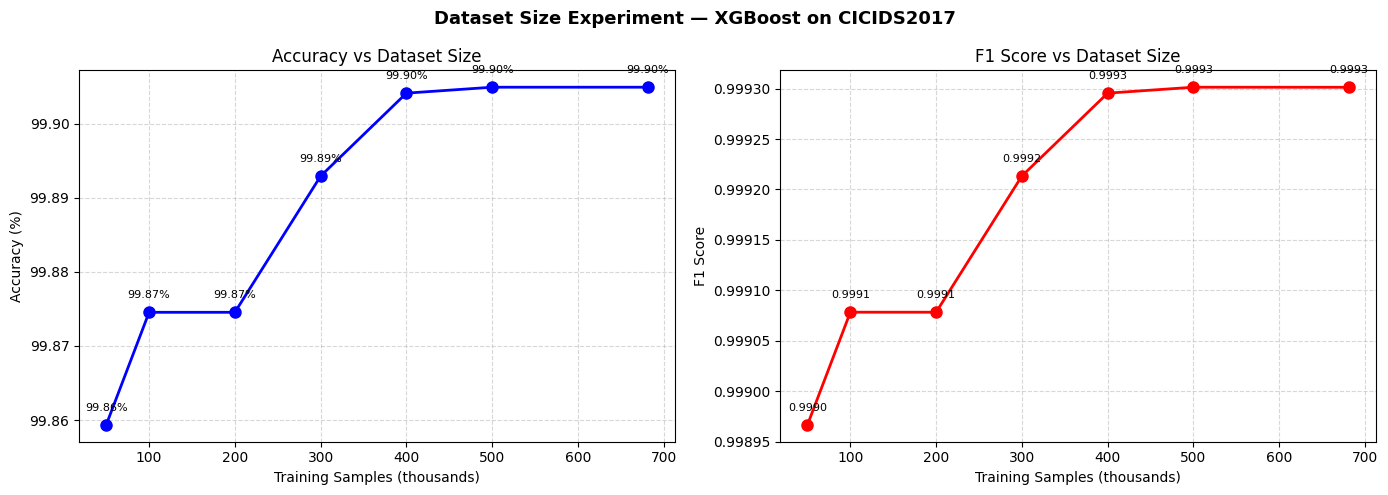


Saved as dataset_size_experiment.png ✓


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score
from xgboost import XGBClassifier
import time

print("=" * 55)
print("DATASET SIZE EXPERIMENT — XGBoost")
print("How much data do we actually need?")
print("=" * 55)

# Different training sizes to test
sizes = [50000, 100000, 200000, 300000, 400000, 500000, 681110]
results = []

for size in sizes:
    # Sample from training data
    if size >= len(X_train_bal):
        X_s = X_train_bal
        y_s = y_train_bal
    else:
        idx = np.random.RandomState(42).choice(
              len(X_train_bal), size, replace=False)
        X_s = X_train_bal[idx]
        y_s = y_train_bal.iloc[idx]

    # Train XGBoost on this subset
    model = XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6,
        random_state=42,
        n_jobs=-1,
        eval_metric='logloss',
        verbosity=0
    )

    start = time.time()
    model.fit(X_s, y_s)
    end = time.time()

    # Test on FULL test set every time
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred)

    results.append({
        'size'    : size,
        'acc'     : acc * 100,
        'f1'      : f1,
        'time'    : round(end - start, 1)
    })

    print(f"Size: {size:>7,} → Acc: {acc*100:.3f}%  "
          f"F1: {f1:.4f}  Time: {round(end-start,1)}s")

# Plot
sizes_k   = [r['size']/1000 for r in results]
accs      = [r['acc'] for r in results]
f1_scores = [r['f1'] for r in results]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Dataset Size Experiment — XGBoost on CICIDS2017',
             fontsize=13, fontweight='bold')

# Accuracy vs Size
axes[0].plot(sizes_k, accs, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Training Samples (thousands)')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_title('Accuracy vs Dataset Size')
axes[0].grid(True, linestyle='--', alpha=0.5)
for x, y in zip(sizes_k, accs):
    axes[0].annotate(f'{y:.2f}%',
                     (x, y),
                     textcoords="offset points",
                     xytext=(0, 10),
                     ha='center', fontsize=8)

# F1 vs Size
axes[1].plot(sizes_k, f1_scores, 'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel('Training Samples (thousands)')
axes[1].set_ylabel('F1 Score')
axes[1].set_title('F1 Score vs Dataset Size')
axes[1].grid(True, linestyle='--', alpha=0.5)
for x, y in zip(sizes_k, f1_scores):
    axes[1].annotate(f'{y:.4f}',
                     (x, y),
                     textcoords="offset points",
                     xytext=(0, 10),
                     ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('dataset_size_experiment.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nSaved as dataset_size_experiment.png ✓")

In [ ]:
from sklearn.metrics import accuracy_score
import numpy as np
import pandas as pd
from xgboost import XGBClassifier

print("=" * 55)
print("FEATURE ABLATION EXPERIMENT")
print("=" * 55)

# ------------------------------------------------
# Experiment 1 — Remove engineered features
# ------------------------------------------------

engineered = [
    'Traffic_Intensity_Index',
    'Flow_Efficiency',
    'Packet_Size_Ratio'
]

# Use the SAME feature list used during training
# (Assumes X was the dataframe before scaling)
feature_names = X.columns.tolist()

# Get indices safely
engineered_idx = [feature_names.index(f)
                  for f in engineered
                  if f in feature_names]

print("\nEngineered features found:", engineered_idx)

# Remove engineered features
X_train_no_eng = np.delete(X_train_bal, engineered_idx, axis=1)
X_test_no_eng  = np.delete(X_test, engineered_idx, axis=1)

# Train model without engineered features
model_no_eng = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss',
    verbosity=0
)

model_no_eng.fit(X_train_no_eng, y_train_bal)

acc_no_eng = accuracy_score(
    y_test,
    model_no_eng.predict(X_test_no_eng)
)

print(f"\nWith all 55 features    : {round(xgb_acc*100, 4)}%")
print(f"Without engineered (52) : {round(acc_no_eng*100, 4)}%")
print(f"Difference              : {round((xgb_acc - acc_no_eng)*100, 4)}%")

# ------------------------------------------------
# Experiment 2 — Top N features only
# ------------------------------------------------

# Get feature importance from Decision Tree
importances = dt.feature_importances_

# Sort features by importance
top_indices = np.argsort(importances)[::-1]

print("\nTop N Features Experiment:")
print(f"{'Features':<12} {'Accuracy':>10}")
print("-" * 25)

for n in [5, 10, 20, 30, 55]:

    top_n_idx = top_indices[:n]

    X_train_n = X_train_bal[:, top_n_idx]
    X_test_n  = X_test[:, top_n_idx]

    model_n = XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6,
        random_state=42,
        n_jobs=-1,
        eval_metric='logloss',
        verbosity=0
    )

    model_n.fit(X_train_n, y_train_bal)

    acc_n = accuracy_score(
        y_test,
        model_n.predict(X_test_n)
    )

    print(f"Top {n:<8} {round(acc_n*100, 3):>10}%")

FEATURE ABLATION EXPERIMENT

Engineered features found: [52, 53, 54]

With all 55 features    : 99.9049%
Without engineered (52) : 99.8969%
Difference              : 0.008%

Top N Features Experiment:
Features       Accuracy
-------------------------
Top 5            99.014%
Top 10           99.543%
Top 20           99.907%
Top 30           99.901%
Top 55           99.907%


In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier

print("\n" + "="*55)
print("LEAKAGE SANITY TEST — LABEL SHUFFLE")
print("="*55)

# Shuffle training labels
y_train_shuffled = np.random.permutation(y_train_bal)

# Train model with shuffled labels
shuffle_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss',
    verbosity=0
)

shuffle_model.fit(X_train_bal, y_train_shuffled)

# Evaluate on real test labels
shuffle_pred = shuffle_model.predict(X_test)

shuffle_acc = accuracy_score(y_test, shuffle_pred)

print(f"\nAccuracy with shuffled labels: {round(shuffle_acc*100, 3)}%")


LEAKAGE SANITY TEST — LABEL SHUFFLE

Accuracy with shuffled labels: 60.386%


In [ ]:
import pandas as pd
import numpy as np

print("\nTop Important Features:\n")

importances = dt.feature_importances_
indices = np.argsort(importances)[::-1]

top_features = []

for i in range(10):
    feature_name = feature_names[indices[i]]
    importance = importances[indices[i]]

    print(f"{i+1}. {feature_name:<35} Importance: {round(importance,4)}")

    top_features.append(feature_name)


Top Important Features:

1. Bwd Packet Length Std               Importance: 0.3963
2. Average Packet Size                 Importance: 0.2816
3. Bwd Header Length                   Importance: 0.1041
4. Destination Port                    Importance: 0.075
5. Max Packet Length                   Importance: 0.043
6. Init_Win_bytes_forward              Importance: 0.0297
7. Packet_Size_Ratio                   Importance: 0.0097
8. Bwd IAT Std                         Importance: 0.007
9. Bwd Packet Length Mean              Importance: 0.0068
10. Flow IAT Mean                       Importance: 0.0065


In [ ]:
print("\n" + "="*55)
print("CROSS-SCENARIO TEST (NO FULL RERUN)")
print("="*55)

# ✅ Recover y safely (without touching pipeline)
y_correct = df_bal['Binary_Label']

# ✅ Recreate X from df_bal (same columns as before)
X_correct = df_bal.drop(['Attack Type', 'Binary_Label'], axis=1)

# Clean like before
X_correct = X_correct.replace([np.inf, -np.inf], np.nan).fillna(0)

# ⚡ Fast split (no scaling yet)
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(
    X_correct, y_correct,
    test_size=0.3,
    random_state=99,
    stratify=y_correct
)

# ⚡ Reuse SAME scaler (IMPORTANT)
X_train_new = scaler.transform(X_train_new)
X_test_new  = scaler.transform(X_test_new)

# ⚡ SMOTE (only this part is heavy but manageable)
smote = SMOTE(random_state=42)
X_train_new, y_train_new = smote.fit_resample(X_train_new, y_train_new)

# ⚡ Reuse XGBoost (fast enough)
xgb_new = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss',
    verbosity=0
)

xgb_new.fit(X_train_new, y_train_new)

# Evaluate
y_pred_new = xgb_new.predict(X_test_new)

from sklearn.metrics import accuracy_score, f1_score, classification_report

new_acc = accuracy_score(y_test_new, y_pred_new)
new_f1  = f1_score(y_test_new, y_pred_new)

print(f"\nUnseen Data Accuracy : {round(new_acc*100, 3)}%")
print(f"Unseen Data F1 Score : {round(new_f1, 4)}")

print("\nClassification Report:")
print(classification_report(y_test_new, y_pred_new))


CROSS-SCENARIO TEST (NO FULL RERUN)

Unseen Data Accuracy : 99.899%
Unseen Data F1 Score : 0.9993

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     60000
           1       1.00      1.00      1.00    127709

    accuracy                           1.00    187709
   macro avg       1.00      1.00      1.00    187709
weighted avg       1.00      1.00      1.00    187709

